In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Owner\Desktop\RA_TASK\Dataset\epl_player_stats_24_25.csv")
df.head()

,Player Name,Club,Nationality,Position,Appearances,Minutes,Goals,Assists,Shots,Shots On Target,...,Fouls,Yellow Cards,Red Cards,Saves,Saves %,Penalties Saved,Clearances Off Line,Punches,High Claims,Goals Prevented
0,Ben White,Arsenal,England,DEF,17,1198,0,2,9,12,...,10,2,0,0,0%,0,0,0,0,0.0
1,Bukayo Saka,Arsenal,England,MID,25,1735,6,10,67,2,...,15,3,0,0,0%,0,0,0,0,0.0
2,David Raya,Arsenal,Spain,GKP,38,3420,0,0,0,0,...,1,3,0,86,72%,0,0,8,53,2.1
3,Declan Rice,Arsenal,England,MID,35,2833,4,7,48,18,...,21,5,1,0,0%,0,0,0,0,0.0
4,Ethan Nwaneri,Arsenal,England,MID,26,889,4,0,24,0,...,9,1,0,0,0%,0,0,0,0,0.0


In [4]:
print(df.shape)
print(df.columns.tolist())


(562, 57)
['Player Name', 'Club', 'Nationality', 'Position', 'Appearances', 'Minutes', 'Goals', 'Assists', 'Shots', 'Shots On Target', 'Conversion %', 'Big Chances Missed', 'Hit Woodwork', 'Offsides', 'Touches', 'Passes', 'Successful Passes', 'Passes%', 'Crosses', 'Successful Crosses', 'Crosses %', 'fThird Passes', 'Successful fThird Passes', 'fThird Passes %', 'Through Balls', 'Carries', 'Progressive Carries', 'Carries Ended with Goal', 'Carries Ended with Assist', 'Carries Ended with Shot', 'Carries Ended with Chance', 'Possession Won', 'Dispossessed', 'Clean Sheets', 'Clearances', 'Interceptions', 'Blocks', 'Tackles', 'Ground Duels', 'gDuels Won', 'gDuels %', 'Aerial Duels', 'aDuels Won', 'aDuels %', 'Goals Conceded', 'xGoT Conceded', 'Own Goals', 'Fouls', 'Yellow Cards', 'Red Cards', 'Saves', 'Saves %', 'Penalties Saved', 'Clearances Off Line', 'Punches', 'High Claims', 'Goals Prevented']


In [5]:
print(df.isnull().sum())


Player Name                  0
Club                         0
Nationality                  0
Position                     0
Appearances                  0
Minutes                      0
Goals                        0
Assists                      0
Shots                        0
Shots On Target              0
Conversion %                 0
Big Chances Missed           0
Hit Woodwork                 0
Offsides                     0
Touches                      0
Passes                       0
Successful Passes            0
Passes%                      0
Crosses                      0
Successful Crosses           0
Crosses %                    0
fThird Passes                0
Successful fThird Passes     0
fThird Passes %              0
Through Balls                0
Carries                      0
Progressive Carries          0
Carries Ended with Goal      0
Carries Ended with Assist    0
Carries Ended with Shot      0
Carries Ended with Chance    0
Possession Won               0
Disposse

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562 entries, 0 to 561
Data columns (total 57 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Player Name                562 non-null    object 
 1   Club                       562 non-null    object 
 2   Nationality                562 non-null    object 
 3   Position                   562 non-null    object 
 4   Appearances                562 non-null    int64  
 5   Minutes                    562 non-null    int64  
 6   Goals                      562 non-null    int64  
 7   Assists                    562 non-null    int64  
 8   Shots                      562 non-null    int64  
 9   Shots On Target            562 non-null    int64  
 10  Conversion %               562 non-null    object 
 11  Big Chances Missed         562 non-null    int64  
 12  Hit Woodwork               562 non-null    int64  
 13  Offsides                   562 non-null    int64  

In [29]:
def top_goal_scorers(df, n=5):
    if "Goals" in df.columns:
        return df[["Player Name", "Club", "Goals"]].sort_values("Goals", ascending=False).head(n)
    else:
        print("⚠️ 'Goals' column not found")
print(top_goal_scorers(df, 20))

              Player Name                     Club  Goals
324         Mohamed Salah                Liverpool     29
391        Alexander Isak         Newcastle United     23
335        Erling Haaland          Manchester City     22
82           Bryan Mbeumo                Brentford     20
417            Chris Wood        Nottingham Forest     20
107           Yoane Wissa                Brentford     19
46          Ollie Watkins              Aston Villa     16
548         Matheus Cunha  Wolverhampton Wanderers     15
141           Cole Palmer                  Chelsea     15
180  Jean-Philippe Mateta           Crystal Palace     14
310            Cody Gakpo                Liverpool     10
155       Nicolas Jackson                  Chelsea     10
127            João Pedro   Brighton & Hove Albion     10
129          Kaoru Mitoma   Brighton & Hove Albion     10
116         Danny Welbeck   Brighton & Hove Albion     10
288           Jamie Vardy           Leicester City      9
203         Il

In [30]:
def top_assist(df, n=5):
    if "Assists" in df.columns:
        return df[["Player Name", "Club", "Assists"]].sort_values("Assists", ascending=False).head(n)
    else:
        print("⚠️ 'Assists' column not found")
print(top_assist(df, 20))

                Player Name                     Club  Assists
324           Mohamed Salah                Liverpool       18
399            Jacob Murphy         Newcastle United       12
415          Anthony Elanga        Nottingham Forest       11
367         Bruno Fernandes        Manchester United       10
45            Morgan Rogers              Aston Villa       10
1               Bukayo Saka                  Arsenal       10
99         Mikkel Damsgaard                Brentford       10
222        Antonee Robinson                   Fulham       10
497           Son Heung-Min        Tottenham Hotspur        9
357                 Savinho          Manchester City        8
514            Jarrod Bowen          West Ham United        8
426      Morgan Gibbs-White        Nottingham Forest        8
141             Cole Palmer                  Chelsea        8
177            Eberechi Eze           Crystal Palace        8
46            Ollie Watkins              Aston Villa        8
14      

In [31]:
def top_clean_sheets(df, n=5):
    # Some datasets have 'Clean Sheets' only for GKs
    if "Clean Sheets" in df.columns:
        gk_df = df[df["Position"].str.contains("GK", na=False)]
        return gk_df[["Player Name", "Club", "Clean Sheets"]].sort_values("Clean Sheets", ascending=False).head(n)
    else:
        print("⚠️ 'Clean Sheets' column not found")
print(top_clean_sheets(df, 20))

           Player Name                     Club  Clean Sheets
2           David Raya                  Arsenal            13
424          Matz Sels        Nottingham Forest            13
210    Jordan Pickford                  Everton            12
176     Dean Henderson           Crystal Palace            11
160     Robert Sánchez                  Chelsea            10
334            Ederson          Manchester City            10
307     Alisson Becker                Liverpool             9
364        André Onana        Manchester United             9
408          Nick Pope         Newcastle United             8
32   Emiliano Martínez              Aston Villa             8
67                Kepa              Bournemouth             8
112    Bart Verbruggen   Brighton & Hove Albion             7
96        Mark Flekken                Brentford             7
544            José Sá  Wolverhampton Wanderers             7
405    Martin Dúbravka         Newcastle United             5
223     

In [11]:
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("Scripts", exist_ok=True)  # only if you really want to save there


In [33]:
top_goal_scorers(df, 20).to_csv("outputs/top_scorers.csv", index=False)
top_assist(df, 20).to_csv("outputs/top_assists.csv", index=False)
top_clean_sheets(df, 20).to_csv("outputs/top_clean_sheets.csv", index=False)


In [13]:
def add_per90(df):
    """Add per90 metrics for goals, assists, and goal contributions."""
    out = df.copy()
    mins = pd.to_numeric(out["Minutes"], errors="coerce").replace(0, np.nan)
    
    out["goals_per90"]   = pd.to_numeric(out["Goals"], errors="coerce")   / (mins/90)
    out["assists_per90"] = pd.to_numeric(out["Assists"], errors="coerce") / (mins/90)
    out["ga_per90"]      = out["goals_per90"] + out["assists_per90"]
    
    return out

# Build player summary
player_summary = (
    add_per90(df)[["Player Name", "Club", "Position", "Minutes", "Goals", "Assists", 
                   "goals_per90", "assists_per90", "ga_per90"]]
)

# Save + preview
player_summary.to_csv("outputs/player_summary.csv", index=False)
display(player_summary)


,Player Name,Club,Position,Minutes,Goals,Assists,goals_per90,assists_per90,ga_per90
0,Ben White,Arsenal,DEF,1198,0,2,0.000000,0.150250,0.150250
1,Bukayo Saka,Arsenal,MID,1735,6,10,0.311239,0.518732,0.829971
2,David Raya,Arsenal,GKP,3420,0,0,0.000000,0.000000,0.000000
3,Declan Rice,Arsenal,MID,2833,4,7,0.127074,0.222379,0.349453
4,Ethan Nwaneri,Arsenal,MID,889,4,0,0.404949,0.000000,0.404949
...,...,...,...,...,...,...,...,...,...
557,Santiago Bueno,Wolverhampton Wanderers,DEF,1682,0,0,0.000000,0.000000,0.000000
558,Tom King,Wolverhampton Wanderers,GKP,1,0,0,0.000000,0.000000,0.000000
559,Tommy Doyle,Wolverhampton Wanderers,MID,475,0,1,0.000000,0.189474,0.189474
560,Toti Gomes,Wolverhampton Wanderers,DEF,2615,0,0,0.000000,0.000000,0.000000


In [14]:
# Custom metrics
def pick(df, *candidates):
    """Return the first existing column name from candidates, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

def per90(series, minutes):
    """Convert raw counts into per-90 rate."""
    m = pd.to_numeric(minutes, errors="coerce").replace(0, np.nan)
    return pd.to_numeric(series, errors="coerce") / (m / 90.0)

def norm01(s):
    """Min–max normalize to [0,1]."""
    s = pd.to_numeric(s, errors="coerce")
    mn, mx = s.min(skipna=True), s.max(skipna=True)
    if pd.isna(mn) or pd.isna(mx) or mx == mn:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mn) / (mx - mn)


In [15]:
def add_cts(df):
    minutes = pick(df, "Minutes")
    xag     = pick(df, "xAG", "Expected Assists")  # if not present, we’ll fallback to Assists
    assists = pick(df, "Assists")
    spass   = pick(df, "Successful Passes", "Passes Completed", "PassesCompleted")
    scross  = pick(df, "Successful Crosses", "Crosses Completed", "CrossesCompleted")

    if minutes is None:
        raise ValueError("Minutes column not found; needed for per-90 metrics.")

    # per-90 components (use assists if xAG missing)
    xag_p90   = per90(df[xag], df[minutes]) if xag else per90(df[assists], df[minutes])
    spass_p90 = per90(df[spass], df[minutes]) if spass else pd.Series(0, index=df.index)
    scross_p90= per90(df[scross], df[minutes]) if scross else pd.Series(0, index=df.index)

    # normalize components to [0,1], then weighted sum
    cts = (
        0.50 * norm01(xag_p90) +
        0.35 * norm01(spass_p90) +
        0.15 * norm01(scross_p90)
    )
    out = df.copy()
    out["CTS"] = cts
    return out

player_summary = add_cts(player_summary)
player_summary.to_csv("outputs/player_summary_with_cts.csv", index=False)

In [16]:
def add_dci(df):
    minutes = pick(df, "Minutes")
    pos     = pick(df, "Position", "Pos")

    tkl  = pick(df, "Tackles", "Tkl")
    intr = pick(df, "Interceptions", "Int")
    clr  = pick(df, "Clearances", "Clr")
    blk  = pick(df, "Blocks", "Blk")  # optional
    sv   = pick(df, "Saves")
    gprev= pick(df, "Goals Prevented")  # some datasets have this for GK

    if minutes is None:
        raise ValueError("Minutes column not found; needed for per-90 metrics.")

    # per-90 for available components
    comps = []
    if tkl:  comps.append(per90(df[tkl],  df[minutes]))
    if intr: comps.append(per90(df[intr], df[minutes]))
    if clr:  comps.append(per90(df[clr],  df[minutes]))
    if blk:  comps.append(per90(df[blk],  df[minutes]))

    base_def = None
    if comps:
        # normalize each component then average to avoid scale issues
        base_def = pd.concat([norm01(c) for c in comps], axis=1).mean(axis=1)
    else:
        base_def = pd.Series(0, index=df.index)

    # GK enhancement (if position indicates GK)
    gk_mask = df[pos].astype(str).str.contains("GK", na=False) if pos else pd.Series(False, index=df.index)
    gk_component = pd.Series(0.0, index=df.index)
    if sv or gprev:
        gk_src = df[sv] if sv else df[gprev]
        gk_component = norm01(per90(gk_src, df[minutes])) * 1.2

    out = df.copy()
    out["DCI"] = base_def + (gk_component.where(gk_mask, 0.0))
    return out

player_summary = add_dci(player_summary)
player_summary.to_csv("outputs/player_summary_with_cts_dci.csv", index=False)

In [17]:
def add_pii(df):
    minutes = pick(df, "Minutes")
    touches = pick(df, "Touches")
    spass   = pick(df, "Successful Passes", "Passes Completed", "PassesCompleted")
    scross  = pick(df, "Successful Crosses", "Crosses Completed", "CrossesCompleted")

    if minutes is None:
        raise ValueError("Minutes column not found; needed for per-90 metrics.")

    touches_p90 = per90(df[touches], df[minutes]) if touches else pd.Series(0, index=df.index)
    spass_p90   = per90(df[spass],   df[minutes]) if spass   else pd.Series(0, index=df.index)
    scross_p90  = per90(df[scross],  df[minutes]) if scross  else pd.Series(0, index=df.index)

    pii = (
        0.20 * norm01(touches_p90) +
        0.60 * norm01(spass_p90)   +
        0.20 * norm01(scross_p90)
    )
    out = df.copy()
    out["PII"] = pii
    return out
player_summary = add_pii(player_summary)
player_summary.to_csv("outputs/player_summary_with_cts_dci_pii.csv", index=False)

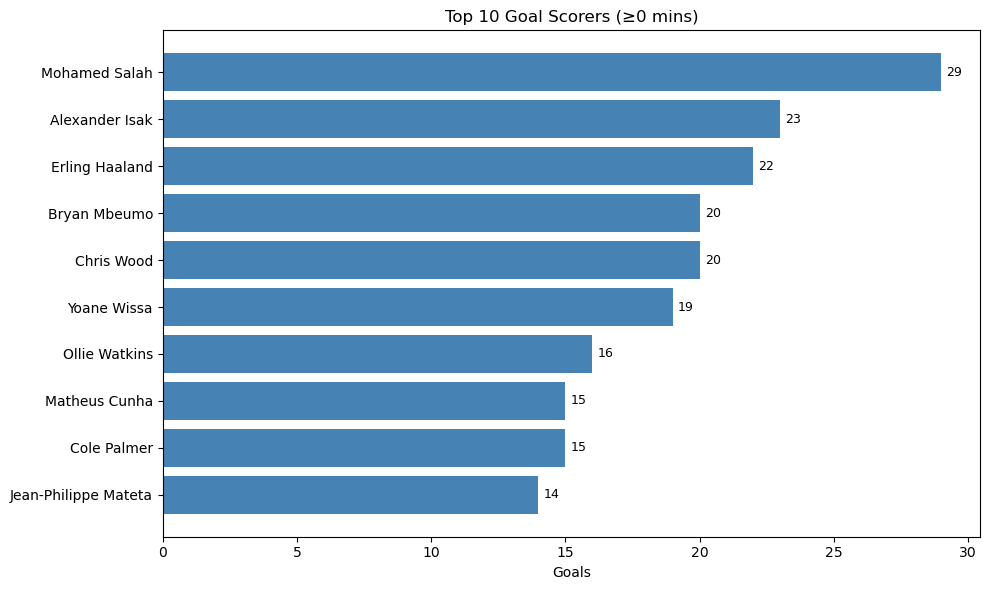

In [21]:
def plot_top_scorers(df, top_n=10, min_minutes=0):
    data = df.copy()
    if "Minutes" in data.columns and min_minutes > 0:
        data = data[data["Minutes"] >= min_minutes]

    data = data.sort_values("Goals", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.barh(data["Player Name"], data["Goals"], color="steelblue")
    ax.invert_yaxis()
    ax.set_xlabel("Goals")
    ax.set_title(f"Top {top_n} Goal Scorers (≥{min_minutes} mins)")

    for i, v in enumerate(data["Goals"]):
        ax.text(v + 0.2, i, str(v), va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("outputs/top_scorers_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_top_scorers(df, top_n=10)


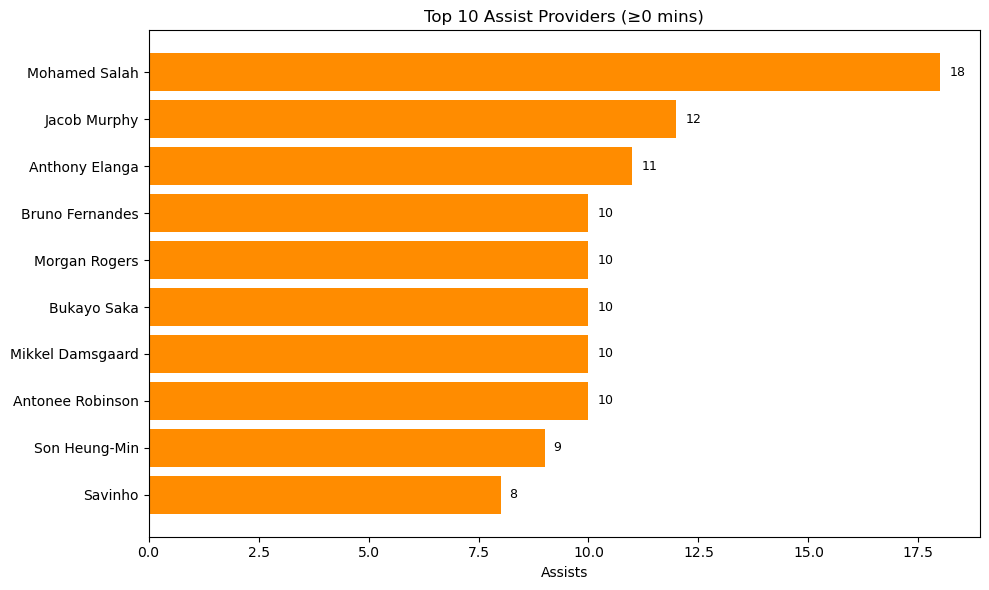

In [22]:
def plot_top_assists(df, top_n=10, min_minutes=0):
    data = df.copy()
    if "Minutes" in data.columns and min_minutes > 0:
        data = data[data["Minutes"] >= min_minutes]

    data = data.sort_values("Assists", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.barh(data["Player Name"], data["Assists"], color="darkorange")
    ax.invert_yaxis()
    ax.set_xlabel("Assists")
    ax.set_title(f"Top {top_n} Assist Providers (≥{min_minutes} mins)")

    for i, v in enumerate(data["Assists"]):
        ax.text(v + 0.2, i, str(v), va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("outputs/top_assists_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_top_assists(df, top_n=10)


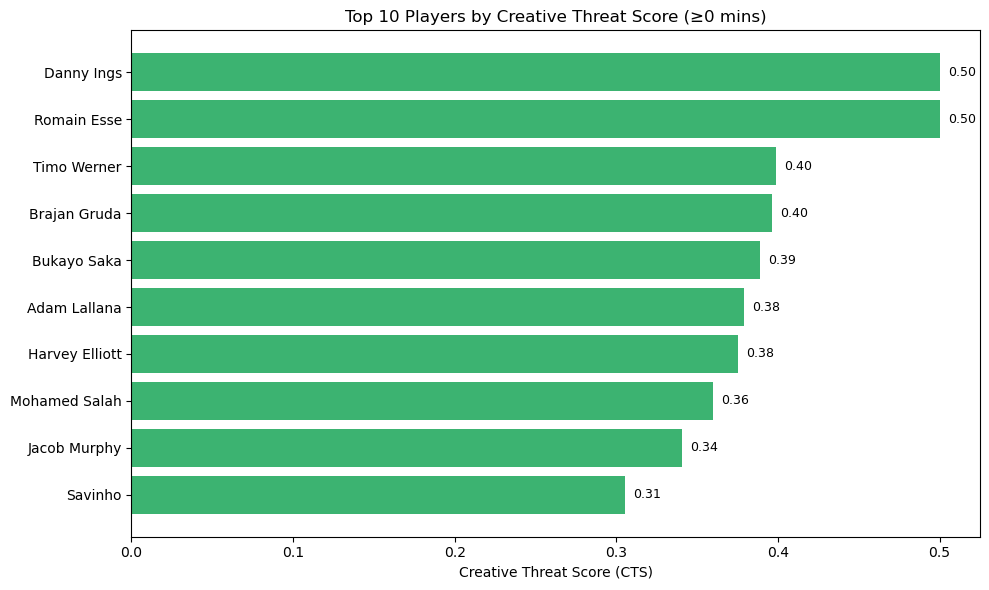

In [24]:
def plot_top_cts(df, top_n=10, min_minutes=0):
    data = df.copy()
    if "Minutes" in data.columns and min_minutes > 0:
        data = data[data["Minutes"] >= min_minutes]

    if "CTS" not in data.columns:
        raise ValueError("CTS column not found! Run add_cts() first.")

    data = data.sort_values("CTS", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.barh(data["Player Name"], data["CTS"], color="mediumseagreen")
    ax.invert_yaxis()
    ax.set_xlabel("Creative Threat Score (CTS)")
    ax.set_title(f"Top {top_n} Players by Creative Threat Score (≥{min_minutes} mins)")

    for i, v in enumerate(data["CTS"]):
        ax.text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("outputs/top_cts_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_top_cts(player_summary, top_n=10)


In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

os.makedirs("outputs", exist_ok=True)

def scatter_cts_vs_goals(df, min_minutes=900, label_top=12, add_trendline=True):
    """
    Plot CTS vs Goals to show creative threat vs actual scoring output.
    - min_minutes: filter to avoid tiny samples (set 0 to disable)
    - label_top: annotate top N points by CTS+Goals (0 to disable)
    - add_trendline: draw a least-squares fit line
    """
    if "CTS" not in df.columns:
        raise ValueError("CTS column not found. Compute it first (add_cts).")
    if "Goals" not in df.columns:
        raise ValueError("Goals column not found.")

    data = df.copy()

    if "Minutes" in data.columns and min_minutes > 0:
        data = data[data["Minutes"] >= min_minutes]

    # numeric & drop NaNs
    x = pd.to_numeric(data["CTS"], errors="coerce")
    y = pd.to_numeric(data["Goals"], errors="coerce")
    mask = x.notna() & y.notna()
    data, x, y = data[mask], x[mask], y[mask]

    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(x, y, alpha=0.75)

    ax.set_xlabel("Creative Threat Score (CTS)")
    ax.set_ylabel("Goals")
    ttl_min = f" (≥{min_minutes} mins)" if ("Minutes" in df.columns and min_minutes > 0) else ""
    ax.set_title(f"CTS vs Goals{ttl_min}")

    # annotate top points by (CTS + Goals)
    if label_top and "Player Name" in data.columns:
        ranked = data.assign(score=x+y).sort_values("score", ascending=False).head(label_top)
        for _, r in ranked.iterrows():
            ax.annotate(
                r["Player Name"],
                (r["CTS"], r["Goals"]),
                xytext=(6,6), textcoords="offset points", fontsize=8
            )

    # optional trendline
    if add_trendline and len(x) >= 2:
        coeffs = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        yy = coeffs[0]*xx + coeffs[1]
        ax.plot(xx, yy, linewidth=2)

        # display R^2
        yhat = coeffs[0]*x + coeffs[1]
        r2 = 1 - ((y - yhat)**2).sum() / ((y - y.mean())**2).sum()
        ax.text(0.02, 0.95, f"trend: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}\n$R^2$ = {r2:.2f}",
                transform=ax.transAxes, va="top", fontsize=9)

    plt.tight_layout()
    plt.savefig("outputs/scatter_cts_vs_goals.png", dpi=300, bbox_inches="tight")
    plt.show()

# usage:
# scatter_cts_vs_goals(player_summary, min_minutes=900, label_top=12, add_trendline=True)
